# TinyML — Quantile Regression Neural Networks (QRNN)

**Author:** Thommas Kevin Sales Flores  
**Institution:** Federal University of Rio Grande do Norte  
**Email:** thommas.flores@ufrn.br

---

This notebook demonstrates how to build, train, evaluate, and export
**Quantile Regression Neural Networks (QRNNs)** to embedded hardware
(Arduino / ESP32) using the TinyML framework.

Unlike standard regression networks that predict only the conditional mean
E[Y|X], a QRNN simultaneously estimates multiple conditional quantiles
Q_τ(Y|X), providing a complete distributional forecast — median, prediction
intervals, and tail risk — in a single forward pass.

### Supported building blocks

| Component | Options |
|---|---|
| **Activation** | `relu`, `tanh`, `sigmoid`, `gelu`, `swish`, `leaky_relu`, `linear` |
| **Loss** | `pinball`, `multi_pinball`, `huber_pinball`, `interval_score`, `coverage`, `combined` |
| **Crossing prevention** | Cumulative-sum reparameterisation in `QuantileHead` |
| **Export** | JSON → Arduino C++ (AVR PROGMEM or ESP32) |


## Environment Setup

Uncomment and run the cell below the first time to install dependencies.


In [1]:
#!pip install torch numpy matplotlib scikit-learn

## 1. Setup and Imports


In [ ]:
import sys, os
sys.path.append('39_QRNN')   # adjust if running from a different directory

import torch
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from model  import QRModel
from layers import get_activation, ACTIVATIONS
from losses import compute_loss, LOSS_NAMES
from utils  import (
    export_to_json,
    train_model,
    plot_training_history,
    plot_quantile_bands,
    plot_quantile_spread,
    plot_calibration,
    plot_residuals,
    plot_feature_importance,
    plot_quantile_crossing,
    evaluate_metrics,
)
from cpp_generator import generate_ino

print('Available loss functions:', LOSS_NAMES)
print('Available activations   :', sorted(ACTIVATIONS.keys()))

os.makedirs('json_model',   exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)

Available loss functions: ['pinball', 'multi_pinball', 'huber_pinball', 'multi_huber_pinball', 'interval_score', 'coverage', 'combined']
Available activations   : ['gelu', 'leaky_relu', 'linear', 'relu', 'sigmoid', 'softmax', 'swish', 'tanh']


---
## 2. Example 1 — Single-Quantile Median Regression

We fit a QRNN to predict the **median** (τ = 0.5) of a noisy sinusoidal
dataset. The pinball loss with τ = 0.5 is equivalent to the Mean Absolute
Error (MAE), so the network learns the conditional median rather than the mean.

This example illustrates the fundamental difference between mean regression
(MSE loss) and median regression (pinball loss): the median is more robust
to outliers and heavy-tailed noise distributions.

=== Example 1 — Single-Quantile Median Regression ===
Parameters: 4,353
  Epoch     1/1000  |  PINBALL = 0.420327
  Epoch   200/1000  |  PINBALL = 0.277712
  Epoch   400/1000  |  PINBALL = 0.277332
  Epoch   600/1000  |  PINBALL = 0.277010
  Epoch   800/1000  |  PINBALL = 0.276898
  Epoch  1000/1000  |  PINBALL = 0.276371


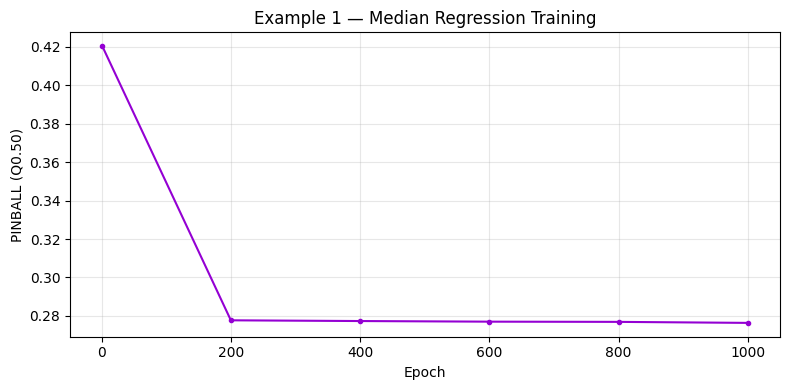

In [3]:
print('=== Example 1 — Single-Quantile Median Regression ===')

# ---- Dataset: y = sin(x) + heavy-tailed noise ----
np.random.seed(0)
N     = 600
x_np  = np.linspace(-5, 5, N).astype(np.float32)
noise = np.random.standard_cauchy(N).clip(-3, 3).astype(np.float32) * 0.4
y_np  = np.sin(x_np) + noise

X = torch.from_numpy(x_np).unsqueeze(1)   # (N, 1)
y = torch.from_numpy(y_np)                 # (N,)

split = int(0.8 * N)
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

# ---- Model ----
model = QRModel(
    hidden_layers=[
        {'in_features': 1,  'out_features': 64, 'activation': 'tanh'},
        {'in_features': 64, 'out_features': 64, 'activation': 'tanh'},
    ],
    quantiles=[0.5],   # median only
)
print(f'Parameters: {model.count_parameters():,}')

optimizer = optim.Adam(model.parameters(), lr=1e-3)
history   = train_model(
    model, X_tr, y_tr, optimizer,
    loss_name='pinball',
    epochs=1000, print_every=200,
    quantile=0.5,
)
plot_training_history(history, loss_name='Pinball (Q0.50)',
                      title='Example 1 — Median Regression Training')

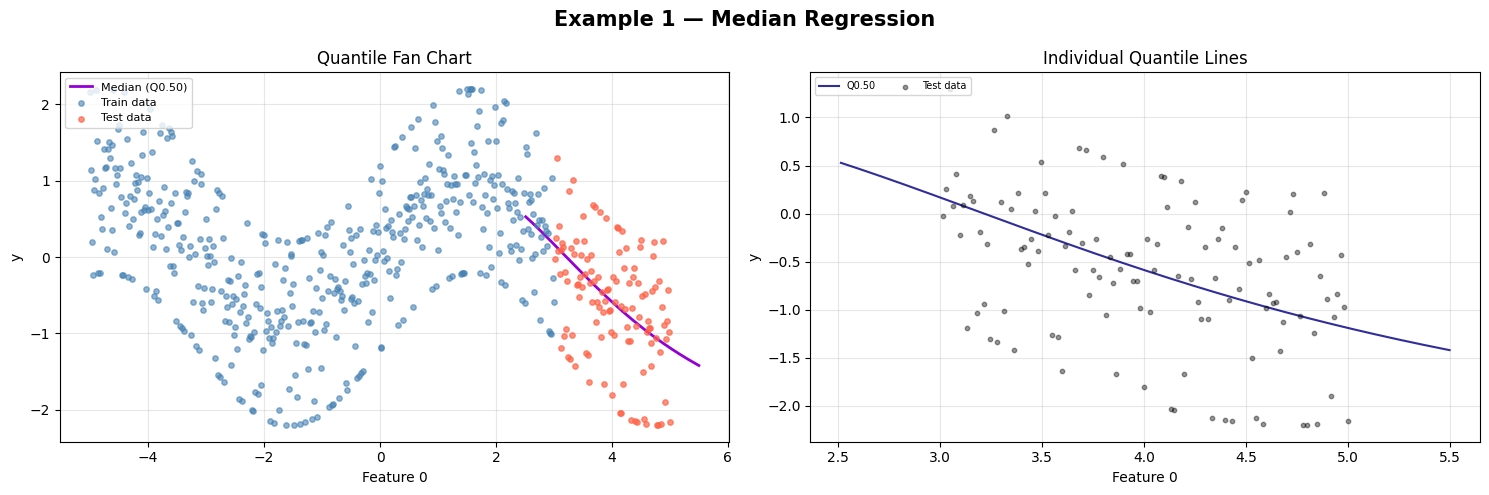

  [evaluate_metrics] Skipping PICP / MPIW / Winkler: lower_q=0.1, upper_q=0.9 not in model quantiles [0.5]. Pass matching lower_q / upper_q to enable interval metrics.

Test metrics:
  pinball_Q0.50        = 0.279514
  pinball_avg          = 0.279514
  median_MAE           = 0.559029


In [4]:
# ---- Evaluate and visualise ----
plot_quantile_bands(
    model, X_tr, y_tr, X_te, y_te,
    quantiles=[0.5],
    title='Example 1 — Median Regression',
)

metrics = evaluate_metrics(model, X_te, y_te, quantiles=[0.5])
print('\nTest metrics:')
for k, v in metrics.items():
    print(f'  {k:20s} = {v:.6f}')

In [5]:
# ---- Export and generate Arduino code ----
export_to_json(model, 'json_model/qr_median.json')
generate_ino(
    json_path='json_model/qr_median.json',
    output_dir='arduino_code/median_ino',
    board='esp32',
    task='regression',
)

Model exported → json_model/qr_median.json
Header  → arduino_code/median_ino\QRNNModel.h
Sketch  → arduino_code/median_ino\sketch.ino
Reference prediction (K=1 quantiles): [0.918313]


---
## 3. Example 2 — Multi-Quantile Regression with Prediction Intervals

We simultaneously estimate **five quantile levels** (0.1, 0.25, 0.5, 0.75, 0.9)
on a heteroskedastic dataset where the noise variance increases with x.

The `QuantileHead` crossing-prevention reparameterisation ensures all five
quantile curves are strictly ordered for every input, without any
post-processing.  The calibration plot verifies that empirical coverage
matches the nominal quantile levels across the test set.

=== Example 2 — Multi-Quantile with Heteroskedastic Noise ===
Parameters: 25,349
  Epoch     1/1500  |  MULTI_PINBALL = 0.468211
  Epoch   300/1500  |  MULTI_PINBALL = 0.333795
  Epoch   600/1500  |  MULTI_PINBALL = 0.323590
  Epoch   900/1500  |  MULTI_PINBALL = 0.324215
  Epoch  1200/1500  |  MULTI_PINBALL = 0.322336
  Epoch  1500/1500  |  MULTI_PINBALL = 0.321837


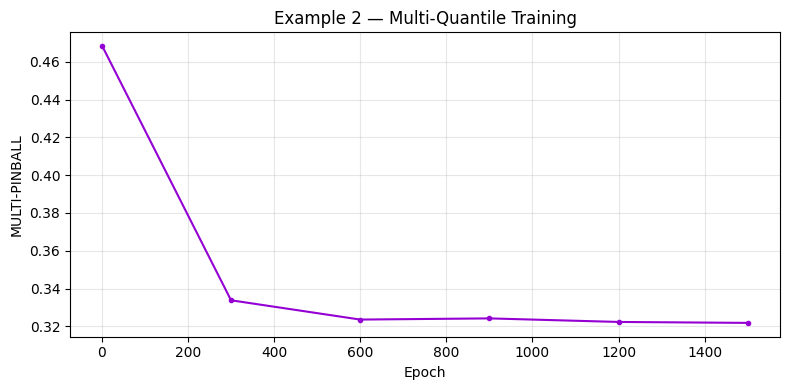

In [6]:
print('=== Example 2 — Multi-Quantile with Heteroskedastic Noise ===')

QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

# ---- Dataset: heteroskedastic noise ----
np.random.seed(42)
N     = 800
x_np  = np.sort(np.random.uniform(-4, 4, N)).astype(np.float32)
sigma = 0.3 + 0.5 * np.abs(x_np)   # noise std grows with |x|
y_np  = np.sin(x_np) + np.random.randn(N).astype(np.float32) * sigma

X = torch.from_numpy(x_np.reshape(-1, 1))   # (N, 1)
y = torch.from_numpy(y_np)                   # (N,)

idx   = int(0.8 * N)
X_tr, X_te = X[:idx], X[idx:]
y_tr, y_te = y[:idx], y[idx:]

# ---- Model ----
model2 = QRModel(
    hidden_layers=[
        {'in_features': 1,   'out_features': 128, 'activation': 'relu'},
        {'in_features': 128, 'out_features': 128, 'activation': 'relu'},
        {'in_features': 128, 'out_features': 64,  'activation': 'relu'},
    ],
    quantiles=QUANTILES,
)
print(f'Parameters: {model2.count_parameters():,}')

optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)
history2   = train_model(
    model2, X_tr, y_tr, optimizer2,
    loss_name='multi_pinball',
    epochs=1500, print_every=300,
    quantiles=QUANTILES,
)
plot_training_history(history2, loss_name='Multi-Pinball',
                      title='Example 2 — Multi-Quantile Training')

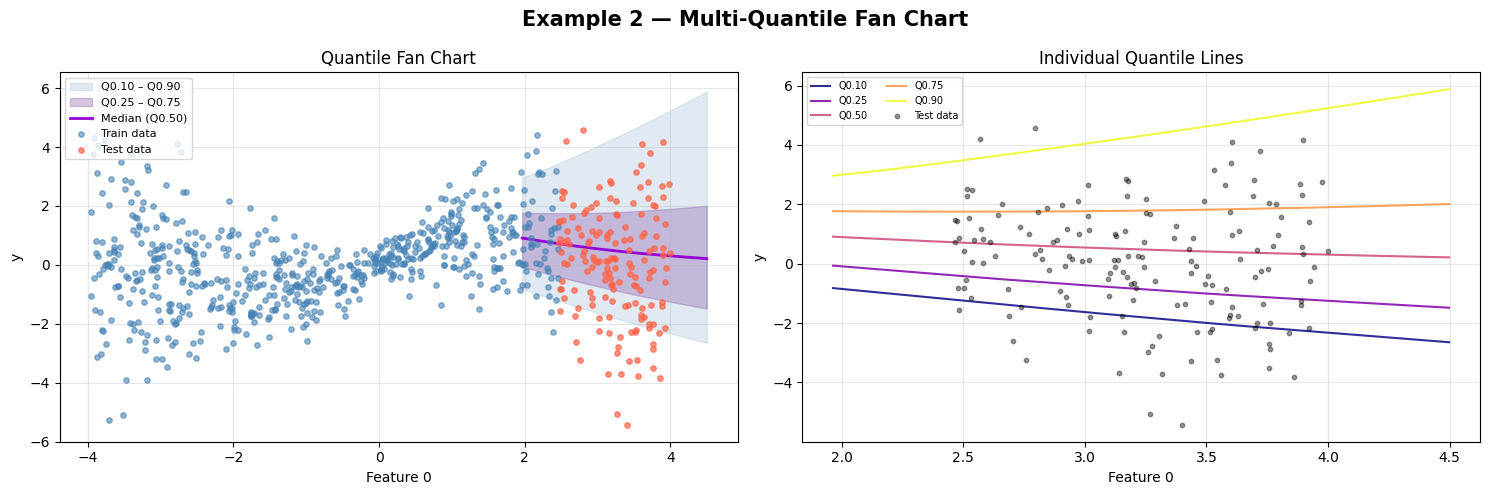

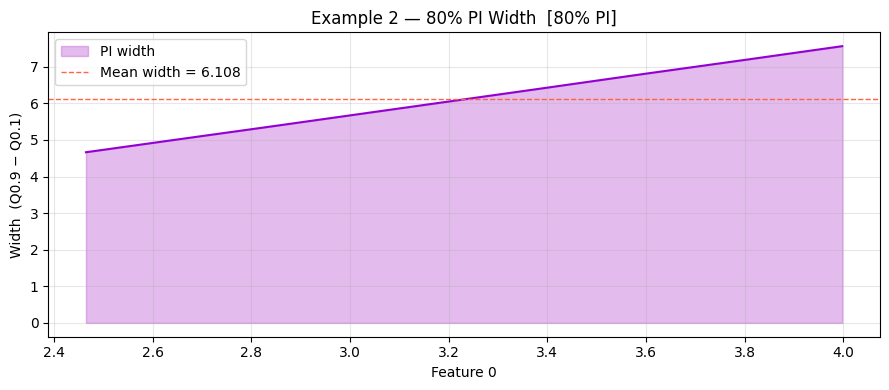

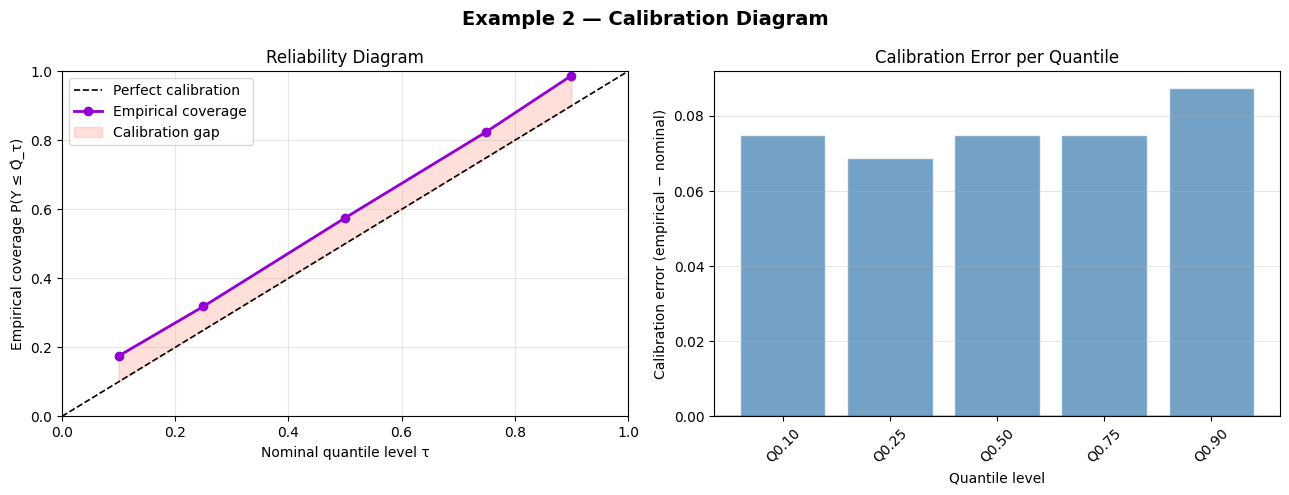

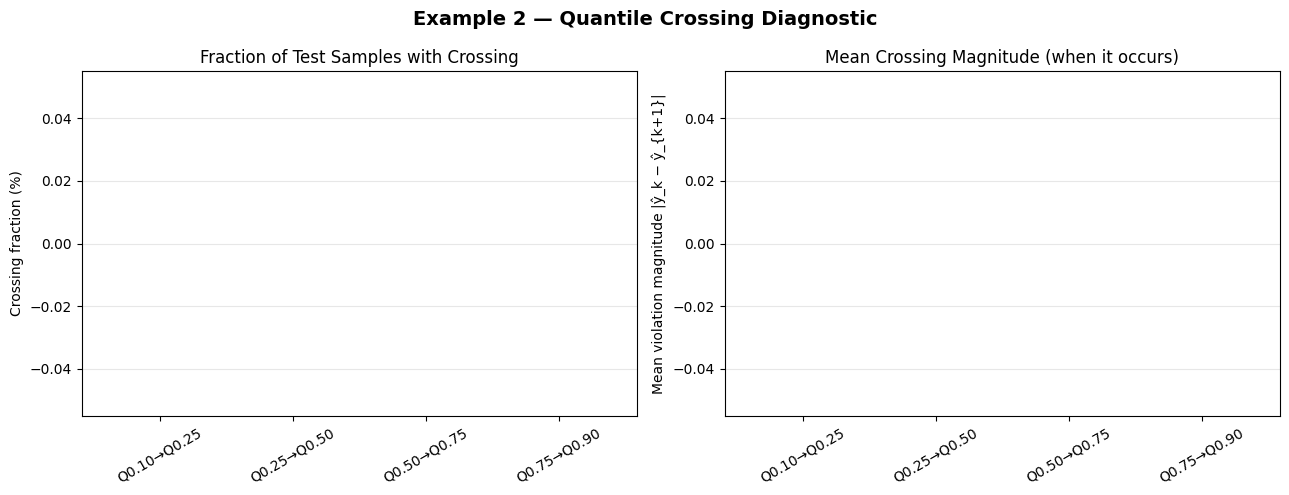


Test metrics:
  pinball_Q0.10             = 0.354044
  pinball_Q0.25             = 0.624806
  pinball_Q0.50             = 0.768562
  pinball_Q0.75             = 0.609371
  pinball_Q0.90             = 0.438375
  pinball_avg               = 0.559031
  PICP                      = 0.812500
  MPIW                      = 6.108118
  Winkler                   = 7.924183
  median_MAE                = 1.537123


In [7]:
# ---- Quantile fan chart ----
plot_quantile_bands(
    model2, X_tr, y_tr, X_te, y_te,
    quantiles=QUANTILES,
    title='Example 2 — Multi-Quantile Fan Chart',
)

# ---- Interval width (heteroskedasticity check) ----
plot_quantile_spread(
    model2, X_te, QUANTILES,
    lower_q=0.1, upper_q=0.9,
    title='Example 2 — 80% PI Width',
)

# ---- Calibration reliability diagram ----
plot_calibration(
    model2, X_te, y_te, QUANTILES,
    title='Example 2 — Calibration Diagram',
)

# ---- Crossing diagnostic ----
plot_quantile_crossing(
    model2, X_te, QUANTILES,
    title='Example 2 — Quantile Crossing Diagnostic',
)

# ---- Metrics ----
metrics2 = evaluate_metrics(model2, X_te, y_te, QUANTILES, lower_q=0.1, upper_q=0.9)
print('\nTest metrics:')
for k, v in metrics2.items():
    print(f'  {k:25s} = {v:.6f}')

In [8]:
export_to_json(model2, 'json_model/qr_multi.json')
generate_ino(
    json_path='json_model/qr_multi.json',
    output_dir='arduino_code/multi_ino',
    board='esp32',
    task='regression',
)

Model exported → json_model/qr_multi.json
Header  → arduino_code/multi_ino\QRNNModel.h
Sketch  → arduino_code/multi_ino\sketch.ino
Reference prediction (K=5 quantiles): [-0.664676  0.069033  0.986747  1.786387  2.806858]


---
## 4. Example 3 — Combined Loss: Pinball + Interval Score + Coverage Penalty

This example trains a QRNN on a multivariate dataset using the **combined loss**,
which jointly optimises:

1. **Multi-pinball** — per-quantile calibration.
2. **Winkler interval score** — rewards narrow prediction intervals.
3. **Coverage penalty** — penalises empirical coverage below the nominal level.

We use the `plot_residuals` and `plot_feature_importance` functions to
understand which covariates drive uncertainty in the predictions.

=== Example 3 — Combined Loss on Multivariate Data ===
Parameters: 25,991
  Epoch     1/2000  |  COMBINED = 2.012049
  Epoch   400/2000  |  COMBINED = 0.213732
  Epoch   800/2000  |  COMBINED = 0.184964
  Epoch  1200/2000  |  COMBINED = 0.174739
  Epoch  1600/2000  |  COMBINED = 0.160056
  Epoch  2000/2000  |  COMBINED = 0.155892


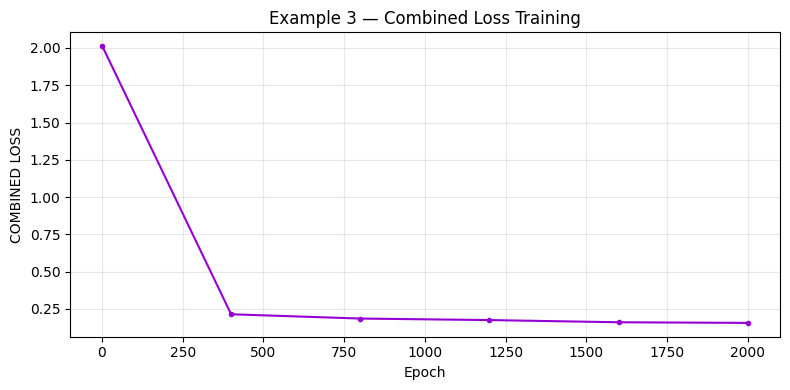

In [9]:
print('=== Example 3 — Combined Loss on Multivariate Data ===')

QUANTILES3 = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
FEATURE_NAMES = ['Age', 'BMI', 'BP', 'Glucose', 'Insulin']

# ---- Dataset: synthetic multivariate regression ----
np.random.seed(7)
N_FEAT = 5
X_raw, y_raw, coef = make_regression(
    n_samples=1200, n_features=N_FEAT,
    noise=25.0, coef=True, random_state=7,
)
# Add heteroskedastic noise driven by feature 0
extra_noise = np.random.randn(1200) * (5.0 + 3.0 * np.abs(X_raw[:, 0]))
y_raw += extra_noise.astype(np.float32)

scaler_X = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw.reshape(-1, 1))
X_sc = scaler_X.transform(X_raw).astype(np.float32)
y_sc = scaler_y.transform(y_raw.reshape(-1, 1)).squeeze().astype(np.float32)

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_sc, y_sc, test_size=0.2, random_state=7
)
X_tr3 = torch.from_numpy(X_tr3)
X_te3 = torch.from_numpy(X_te3)
y_tr3 = torch.from_numpy(y_tr3)
y_te3 = torch.from_numpy(y_te3)

# ---- Model ----
model3 = QRModel(
    hidden_layers=[
        {'in_features': N_FEAT, 'out_features': 128, 'activation': 'relu', 'dropout': 0.1},
        {'in_features': 128,    'out_features': 128, 'activation': 'relu', 'dropout': 0.1},
        {'in_features': 128,    'out_features': 64,  'activation': 'relu'},
    ],
    quantiles=QUANTILES3,
)
print(f'Parameters: {model3.count_parameters():,}')

optimizer3 = optim.Adam(model3.parameters(), lr=5e-4, weight_decay=1e-5)
history3   = train_model(
    model3, X_tr3, y_tr3, optimizer3,
    loss_name='combined',
    epochs=2000, print_every=400,
    quantiles=QUANTILES3,
    alpha=0.1,
    lambda_is=0.05,
    lambda_cv=0.05,
)
plot_training_history(history3, loss_name='Combined Loss',
                      title='Example 3 — Combined Loss Training')

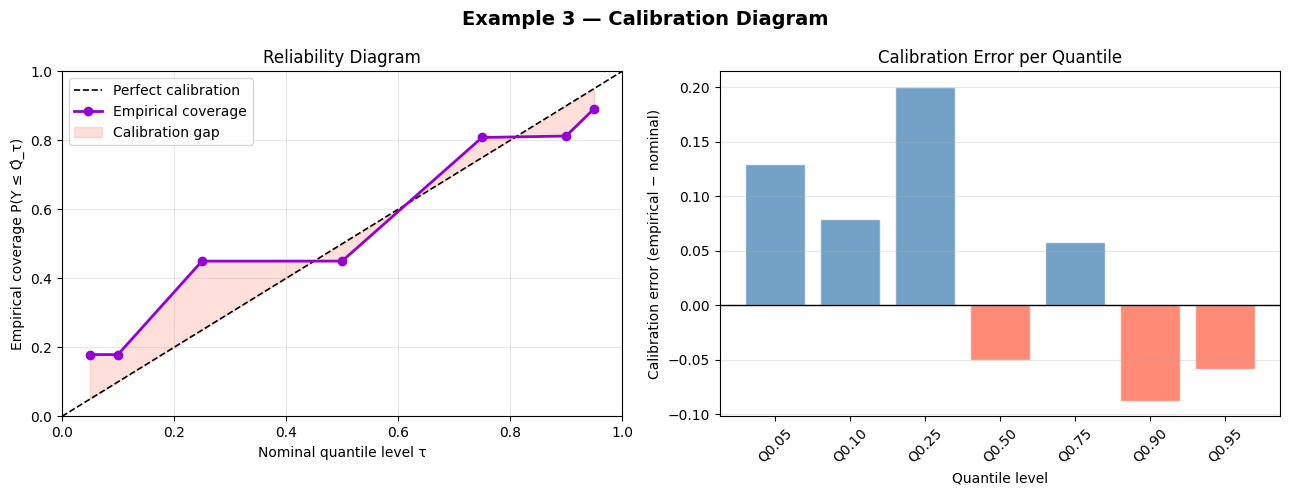

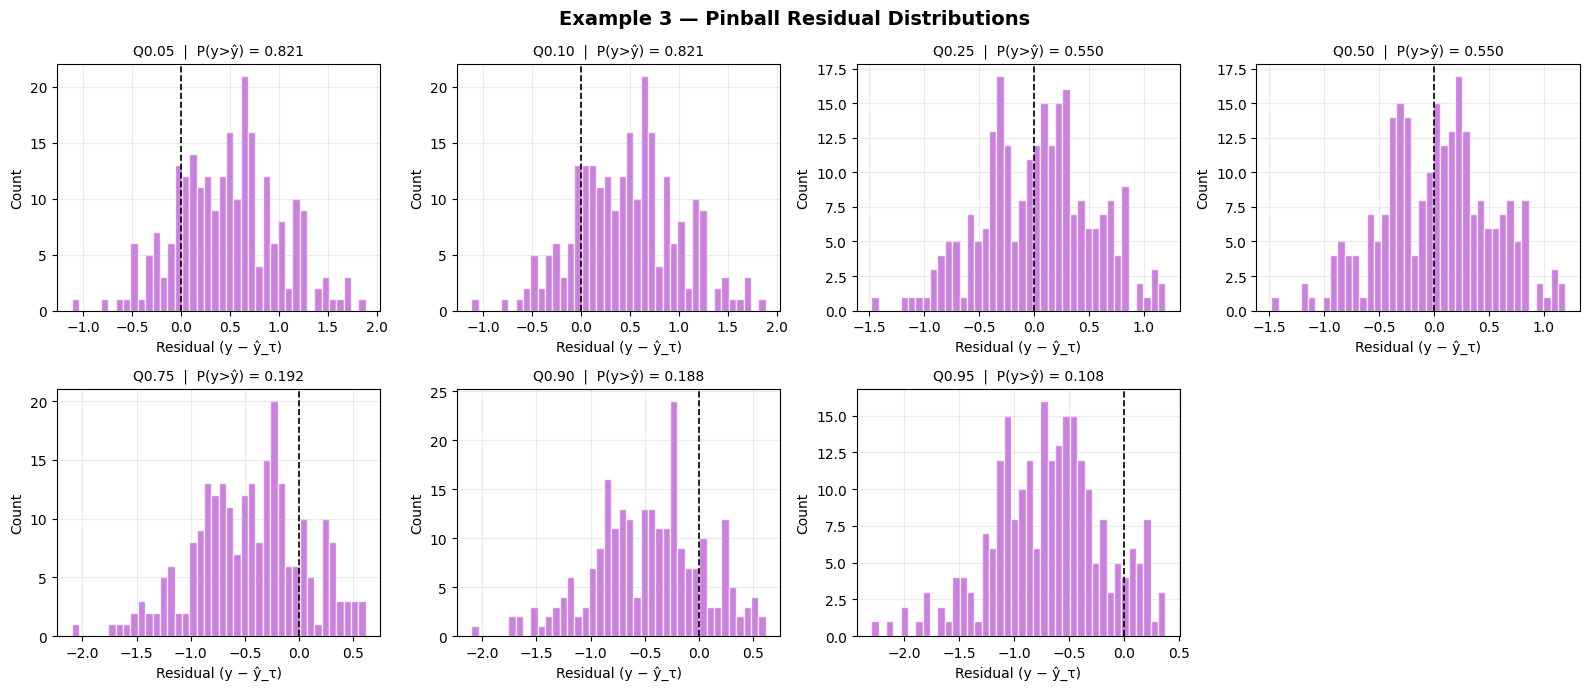

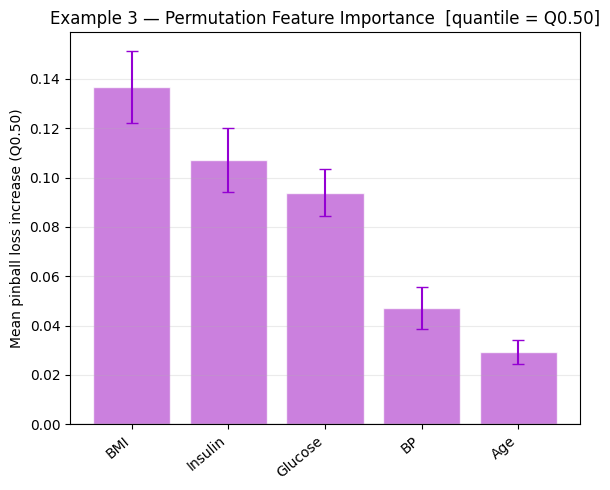


Feature importances (Q0.50):
  Age       : 0.0293
  BMI       : 0.1368
  BP        : 0.0472
  Glucose   : 0.0939
  Insulin   : 0.1071

Test metrics (90% PI):
  pinball_Q0.05             = 0.072072
  pinball_Q0.10             = 0.096071
  pinball_Q0.25             = 0.194757
  pinball_Q0.50             = 0.203216
  pinball_Q0.75             = 0.161936
  pinball_Q0.90             = 0.092949
  pinball_Q0.95             = 0.051663
  pinball_avg               = 0.124666
  PICP                      = 0.712500
  MPIW                      = 1.161345
  Winkler                   = 2.474701
  median_MAE                = 0.406432


In [10]:
# ---- Calibration, residuals, and feature importance ----
plot_calibration(
    model3, X_te3, y_te3, QUANTILES3,
    title='Example 3 — Calibration Diagram',
)

plot_residuals(
    model3, X_te3, y_te3, QUANTILES3,
    title='Example 3 — Pinball Residual Distributions',
)

imp = plot_feature_importance(
    model3, X_te3, y_te3, QUANTILES3,
    feature_names=FEATURE_NAMES,
    n_repeats=20,
    target_q_idx=3,   # median
    title='Example 3 — Permutation Feature Importance',
)

print('\nFeature importances (Q0.50):')
for name, score in zip(FEATURE_NAMES, imp):
    print(f'  {name:10s}: {score:.4f}')

metrics3 = evaluate_metrics(model3, X_te3, y_te3, QUANTILES3,
                             lower_q=0.05, upper_q=0.95)
print('\nTest metrics (90% PI):')
for k, v in metrics3.items():
    print(f'  {k:25s} = {v:.6f}')

In [11]:
export_to_json(model3, 'json_model/qr_combined.json')
generate_ino(
    json_path='json_model/qr_combined.json',
    output_dir='arduino_code/combined_ino',
    board='avr',
    use_flash=True,
    task='regression',
)

Model exported → json_model/qr_combined.json
Header  → arduino_code/combined_ino\QRNNModel.h
Sketch  → arduino_code/combined_ino\sketch.ino
Reference prediction (K=7 quantiles): [1.670102 1.670102 2.053185 2.053186 2.874531 2.874687 3.011625]


---
## 5. Example 4 — Huber-Pinball Loss for Robust Tail Estimation

This example demonstrates the **Huber-smoothed pinball loss** on a dataset
with extreme outliers.  The Huber-pinball loss reduces gradient noise near
zero by replacing the non-differentiable kink with a smooth quadratic region,
making training more stable when the response distribution has heavy tails.

We train two models — one with the standard pinball loss and one with
Huber-pinball — and compare their tail quantile estimates (Q0.05 and Q0.95).

In [16]:
QUANTILES4 = [0.05, 0.5, 0.95]

# ----------------------------------------------
# Dataset: heavy-tailed (Student-t noise, df=3)
# ----------------------------------------------

np.random.seed(123)

N = 1000

x4 = np.sort(np.random.uniform(-6, 6, N)).astype(np.float32)

nu = 3  # degrees of freedom

eps = np.random.standard_t(nu, N).astype(np.float32) * 0.8

y4 = 0.5 * x4 + np.sin(x4) + eps

X4 = torch.from_numpy(x4.reshape(-1, 1))

y4t = torch.from_numpy(y4)

split4 = int(0.8 * N)

X4_tr, X4_te = X4[:split4], X4[split4:]
y4_tr, y4_te = y4t[:split4], y4t[split4:]


def _build_model4():
    return QRModel(
        hidden_layers=[
            {
                'in_features': 1,
                'out_features': 64,
                'activation': 'relu'
            },
            {
                'in_features': 64,
                'out_features': 64,
                'activation': 'relu'
            },
        ],
        quantiles=QUANTILES4,
    )


# ----------------------------------------------
# Standard pinball
# ----------------------------------------------

model4a = _build_model4()

opt4a = optim.Adam(model4a.parameters(), lr=1e-3)

print('Training with standard multi-pinball...')

history4a = train_model(
    model4a,
    X4_tr,
    y4_tr,
    opt4a,
    loss_name='multi_pinball',
    epochs=1000,
    print_every=250,
    quantiles=QUANTILES4,
)


# ----------------------------------------------
# Huber-pinball across all K quantiles simultaneously
# ----------------------------------------------

# multi_huber_pinball applies the Huber-smoothed check function to every
# output column, giving smoother gradients on heavy-tailed data while
# still estimating all three quantile levels in a single forward pass.

model4b = _build_model4()

opt4b = optim.Adam(model4b.parameters(), lr=1e-3)

print('\nTraining with multi-Huber-pinball (all quantiles, delta=0.5)...')

history4b = train_model(
    model4b,
    X4_tr,
    y4_tr,
    opt4b,
    loss_name='multi_huber_pinball',
    epochs=1000,
    print_every=250,
    quantiles=QUANTILES4,
    delta=0.5,
)

Training with standard multi-pinball...
  Epoch     1/1000  |  MULTI_PINBALL = 2.344023
  Epoch   250/1000  |  MULTI_PINBALL = 0.249909
  Epoch   500/1000  |  MULTI_PINBALL = 0.235619
  Epoch   750/1000  |  MULTI_PINBALL = 0.229926
  Epoch  1000/1000  |  MULTI_PINBALL = 0.228344

Training with multi-Huber-pinball (all quantiles, delta=0.5)...
  Epoch     1/1000  |  MULTI_HUBER_PINBALL = -0.676398
  Epoch   250/1000  |  MULTI_HUBER_PINBALL = -444.876831
  Epoch   500/1000  |  MULTI_HUBER_PINBALL = -2894.767578
  Epoch   750/1000  |  MULTI_HUBER_PINBALL = -8822.409180
  Epoch  1000/1000  |  MULTI_HUBER_PINBALL = -19321.322266


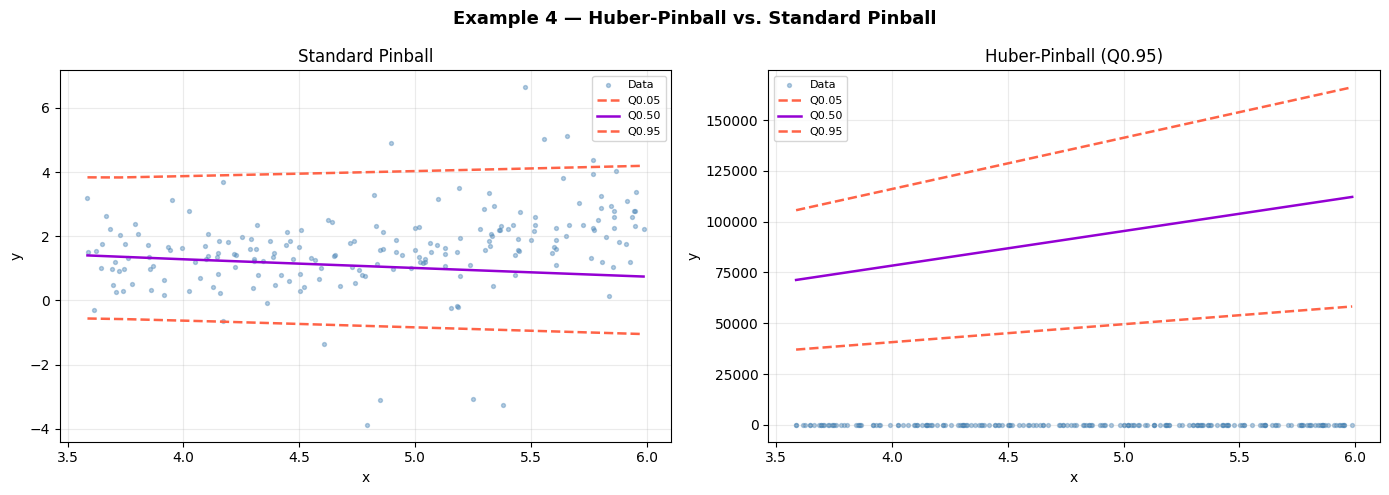


--- Standard Pinball ---
  pinball_Q0.05             = 0.173160
  pinball_Q0.50             = 0.524970
  pinball_Q0.95             = 0.147403
  pinball_avg               = 0.281844
  PICP                      = 0.950000
  MPIW                      = 4.807196
  Winkler                   = 6.411258
  median_MAE                = 1.049940

--- Huber-Pinball ---
  pinball_Q0.05             = 45571.941406
  pinball_Q0.50             = 46187.339844
  pinball_Q0.95             = 6842.013672
  pinball_avg               = 32867.098307
  PICP                      = 0.000000
  MPIW                      = 88869.812500
  Winkler                   = 1048279.062500
  median_MAE                = 92374.687500


In [14]:
# ---- Compare calibration of both models ----
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Example 4 — Huber-Pinball vs. Standard Pinball', fontsize=13, fontweight='bold')

for ax, model4, label in zip(
    axes,
    [model4a, model4b],
    ['Standard Pinball', 'Huber-Pinball (Q0.95)'],
):
    model4.eval()
    with torch.no_grad():
        q_te = model4(X4_te).numpy() if hasattr(model4(X4_te), 'numpy') else model4(X4_te).detach().numpy()
    x_te_np = X4_te.squeeze().numpy()
    sort_idx = np.argsort(x_te_np)
    ax.scatter(x_te_np, y4_te.numpy(), c='steelblue', s=8, alpha=0.4, label='Data')
    colors_q = ['tomato', 'darkviolet', 'tomato']
    ls_q     = ['--', '-', '--']
    for k, q in enumerate(QUANTILES4):
        ax.plot(x_te_np[sort_idx], q_te[sort_idx, k],
                color=colors_q[k], linestyle=ls_q[k], linewidth=1.8,
                label=f'Q{q:.2f}')
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ---- Metrics comparison ----
m4a = evaluate_metrics(model4a, X4_te, y4_te, QUANTILES4, lower_q=0.05, upper_q=0.95)
m4b = evaluate_metrics(model4b, X4_te, y4_te, QUANTILES4, lower_q=0.05, upper_q=0.95)

print('\n--- Standard Pinball ---')
for k, v in m4a.items():
    print(f'  {k:25s} = {v:.6f}')

print('\n--- Huber-Pinball ---')
for k, v in m4b.items():
    print(f'  {k:25s} = {v:.6f}')

In [15]:
export_to_json(model4a, 'json_model/qr_huber.json')
generate_ino(
    json_path='json_model/qr_huber.json',
    output_dir='arduino_code/huber_ino',
    board='esp32',
    task='regression',
)

Model exported → json_model/qr_huber.json
Header  → arduino_code/huber_ino\QRNNModel.h
Sketch  → arduino_code/huber_ino\sketch.ino
Reference prediction (K=3 quantiles): [-0.381008  1.953641  3.928586]
